In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Carregar dados

In [3]:
df = pd.read_csv("Train_data.csv")

# Visualização inicial
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


###  Pré-processamento dos dados

In [4]:
# Colunas categóricas nominais
colunas_categoricas = ['protocol_type', 'flag', 'service']

# Dicionário para armazenar os encoders caso precise inverter depois
encoders = {}

for coluna in colunas_categoricas:
    le = LabelEncoder()
    df[coluna] = le.fit_transform(df[coluna])
    encoders[coluna] = le  # Guarda o encoder para possível inversão futura

# Renomeando para Label para evitar confusão
df.rename(columns={'class': 'Label'}, inplace=True)

# Codificar a coluna alvo
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])

### Divisao treino e teste

In [6]:
# Separar atributos e rótulo
X = df.drop('Label', axis=1)
y = df['Label']

# Dividir em treino e teste (random_state para reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Colocar os dados na mesma escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Treino: {X_train_scaled.shape}, Teste: {X_test_scaled.shape}')

Treino: (17634, 41), Teste: (7558, 41)


### Treinamento do Modelo

In [7]:
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)

# Treinar o modelo
modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Avaliacao do Modelo

Acurácia: 0.9558084149

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3523
           1       0.95      0.97      0.96      4035

    accuracy                           0.96      7558
   macro avg       0.96      0.95      0.96      7558
weighted avg       0.96      0.96      0.96      7558



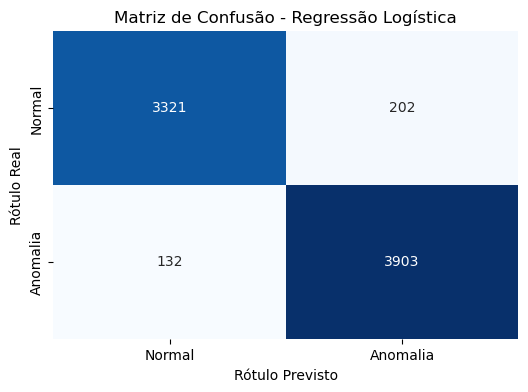

In [8]:
# Realizar as previsões
y_pred = modelo_logistico.predict(X_test_scaled)

# Acurácia geral
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.10f}\n")

# Relatório
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Anomalia'], yticklabels=['Normal', 'Anomalia'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Real')
plt.show()

### Interpretação

Top 10 Atributos de Maior Peso no Modelo (Magnitude |w|):
num_compromised       3.146041
num_root              2.544804
srv_serror_rate       2.288762
count                 1.733113
srv_rerror_rate       1.732345
flag                  1.470499
dst_host_srv_count    1.430819
wrong_fragment        1.298295
su_attempted          1.178461
same_srv_rate         1.162017
dtype: float64


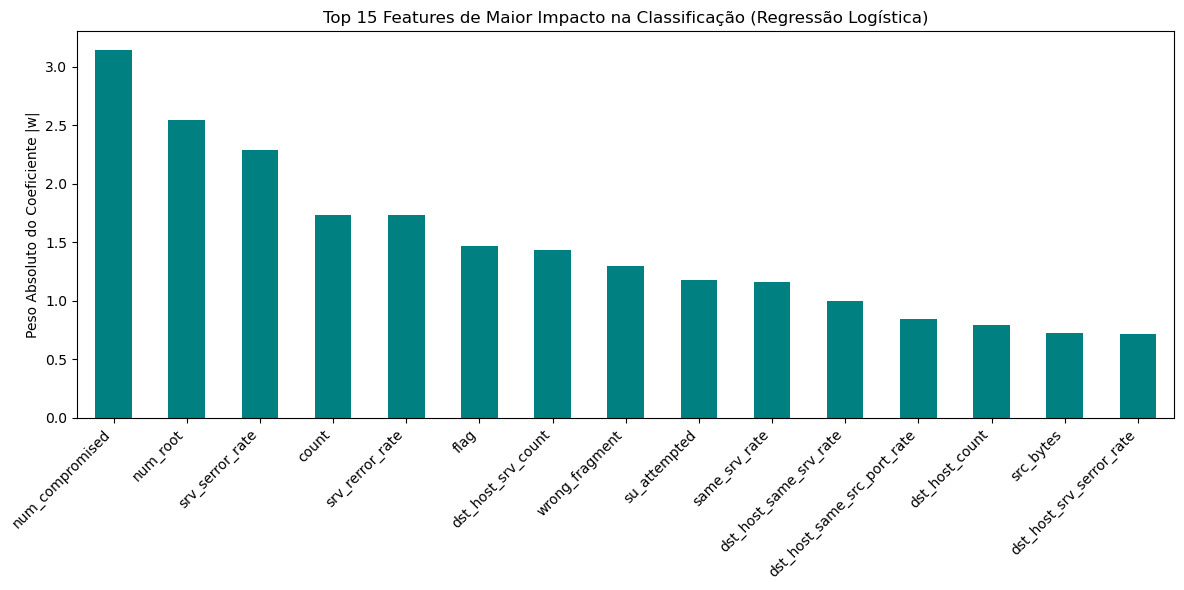

In [9]:
# Obter os coeficientes do modelo e calcular o seu valor absoluto
importancias_lr = pd.Series(np.abs(modelo_logistico.coef_[0]), index=X.columns).sort_values(ascending=False)

print("Top 10 Atributos de Maior Peso no Modelo (Magnitude |w|):")
print(importancias_lr.head(10))

# Visualização gráfica
plt.figure(figsize=(12, 6))
importancias_lr.head(15).plot(kind='bar', color='teal')
plt.title("Top 15 Features de Maior Impacto na Classificação (Regressão Logística)")
plt.ylabel("Peso Absoluto do Coeficiente |w|")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()